In [1]:
import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image

import kagglehub

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision import models as tv_models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

# Dataset root
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(f"Dataset path: {path}")

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Dataset path: /kaggle/input/gtsrb-german-traffic-sign


In [2]:
TRAIN_DIR   = os.path.join(path, "Train")
TEST_DIR    = os.path.join(path, "Test")
TEST_CSV    = os.path.join(path, "Test.csv")

In [3]:
NUM_CLASSES = 43
CLASS_NAMES = {
    0:'Speed limit (20)',    1:'Speed limit (30)',   2:'Speed limit (50)',
    3:'Speed limit (60)',    4:'Speed limit (70)',   5:'Speed limit (80)',
    6:'End speed limit(80)', 7:'Speed limit (100)',  8:'Speed limit (120)',
    9:'No passing',         10:'No passing >3.5t',  11:'Right-of-way',
    12:'Priority road',     13:'Yield',              14:'Stop',
    15:'No vehicles',       16:'No >3.5t vehicles', 17:'No entry',
    18:'General caution',   19:'Danger curve left', 20:'Danger curve right',
    21:'Double curve',      22:'Bumpy road',         23:'Slippery road',
    24:'Road narrows',      25:'Road work',          26:'Traffic signals',
    27:'Pedestrians',       28:'Children crossing',  29:'Bicycles crossing',
    30:'Ice/snow',          31:'Wild animals',       32:'End speed+passing',
    33:'Turn right ahead',  34:'Turn left ahead',    35:'Ahead only',
    36:'Go straight/right', 37:'Go straight/left',   38:'Keep right',
    39:'Keep left',         40:'Roundabout',          41:'End no passing',
    42:'End no passing >3.5t'
}

In [4]:
print("Loading data from folder structure...")

train_paths = []
train_labels = []

# Load train data from class folders
for class_id in tqdm(range(NUM_CLASSES), desc="Scanning train class folders"):
    class_folder = os.path.join(TRAIN_DIR, str(class_id))
    if not os.path.exists(class_folder):
        continue

    for img_file in os.listdir(class_folder):
        if img_file.endswith('.png'):
            img_path = os.path.join(class_folder, img_file)
            train_paths.append(img_path)
            train_labels.append(class_id)

print(f"Total training images found: {len(train_paths):,}")

# Load test data from CSV to keep correct label order
test_df = pd.read_csv(TEST_CSV)
test_paths = [os.path.join(path, p) for p in test_df['Path'].values]
test_labels = test_df['ClassId'].values.tolist()

print(f"Total test images found: {len(test_paths):,}")

Loading data from folder structure...


Scanning train class folders: 100%|██████████| 43/43 [00:00<00:00, 67.06it/s]

Total training images found: 39,209
Total test images found: 12,630


In [5]:
#print the shape of the first image to verify loading
if train_paths:
    sample_image = Image.open(train_paths[50])
    print(f"Sample image size: {sample_image.size} (width x height)")

Sample image size: (34, 36) (width x height)


In [6]:
#load images into train data frame
data_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

In [7]:
class MyImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image lazily (only when needed)
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
# Split paths and labels (80% train, 20% validation)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths,
    train_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=train_labels
)

# Create datasets
train_ds = MyImageDataset(train_paths, train_labels, transform=data_transforms)
val_ds = MyImageDataset(val_paths, val_labels, transform=data_transforms)
test_ds = MyImageDataset(test_paths, test_labels, transform=data_transforms)

# Fast dataloader settings
BATCH_SIZE = 64
NUM_WORKERS = min(8, os.cpu_count() or 2)
PIN_MEMORY = torch.cuda.is_available()

if NUM_WORKERS > 0:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                              pin_memory=PIN_MEMORY, persistent_workers=True, prefetch_factor=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                            pin_memory=PIN_MEMORY, persistent_workers=True, prefetch_factor=2)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                             pin_memory=PIN_MEMORY, persistent_workers=True, prefetch_factor=2)
else:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train/Val/Test sizes: {len(train_ds):,} / {len(val_ds):,} / {len(test_ds):,}")
print(f"DataLoader workers: {NUM_WORKERS} | pin_memory={PIN_MEMORY}")

Train/Val/Test sizes: 31,367 / 7,842 / 12,630
DataLoader workers: 2 | pin_memory=True


In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        # Feature Extraction
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # Classification Head
        # If input 64x64, after two 2x2 pools it becomes 16x16
        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [10]:
# Deep CNN training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def make_optimizer(model, name, lr):
    if name == "adam":
        return optim.Adam(model.parameters(), lr=lr)
    if name == "sgd":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True)
    raise ValueError("Unsupported optimizer")

def make_scheduler(optimizer, name):
    if name == "step":
        return optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)
    if name == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
    raise ValueError("Unsupported scheduler")

criterion_cls = nn.CrossEntropyLoss()

Using device: cuda


In [11]:
def evaluate_classifier(model, data_loader, device):
    model.eval()
    all_preds, all_targets = [], []

    with torch.inference_mode():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
                outputs = model(images)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    return acc, all_targets, all_preds


def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if scaler is not None and device.type == "cuda":
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


def train_cnn(num_epochs, train_loader, val_loader, model, criterion, optimizer, scheduler, device):
    history = {"train_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler=scaler)
        scheduler.step()

        val_acc, _, _ = evaluate_classifier(model, val_loader, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)

        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f} | Val Acc: {val_acc*100:.2f}% | LR: {current_lr:.6f}"
        )

    model.load_state_dict(best_state)
    return model, history, best_val_acc

In [12]:
# Compare optimizers and learning rate schedulers on Deep CNN
cnn_configs = [
    {"optimizer": "adam", "scheduler": "step", "lr": 1e-3},
    {"optimizer": "sgd", "scheduler": "cosine", "lr": 5e-3},
]

NUM_EPOCHS_CNN = 5
cnn_results = []
cnn_best_model = None
cnn_best_test_acc = -1.0

for cfg in cnn_configs:
    print("\n" + "=" * 70)
    print(f"Deep CNN | Optimizer={cfg['optimizer']} | Scheduler={cfg['scheduler']} | LR={cfg['lr']}")
    print("=" * 70)

    model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
    optimizer = make_optimizer(model, cfg["optimizer"], cfg["lr"])
    scheduler = make_scheduler(optimizer, cfg["scheduler"])

    model, history, best_val_acc = train_cnn(
        num_epochs=NUM_EPOCHS_CNN,
        train_loader=train_loader,
        val_loader=val_loader,
        model=model,
        criterion=criterion_cls,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
    )

    test_acc, y_true_test, y_pred_test = evaluate_classifier(model, test_loader, device)

    cnn_results.append({
        "Optimizer": cfg["optimizer"],
        "Scheduler": cfg["scheduler"],
        "LR": cfg["lr"],
        "Best Val Acc": best_val_acc,
        "Test Acc": test_acc,
    })

    if test_acc > cnn_best_test_acc:
        cnn_best_test_acc = test_acc
        cnn_best_model = model
        cnn_best_targets = y_true_test
        cnn_best_preds = y_pred_test

cnn_results_df = pd.DataFrame(cnn_results).sort_values(by="Test Acc", ascending=False)
print("\nDeep CNN Comparison (Optimizer + Scheduler):")
print(cnn_results_df.to_string(index=False))

print("\nBest Deep CNN classification report on test set:")
print(classification_report(cnn_best_targets, cnn_best_preds, digits=3))


Deep CNN | Optimizer=adam | Scheduler=step | LR=0.001
Epoch [1/5] | Train Loss: 0.9413 | Val Acc: 91.23% | LR: 0.001000
Epoch [2/5] | Train Loss: 0.1513 | Val Acc: 96.45% | LR: 0.001000
Epoch [3/5] | Train Loss: 0.0852 | Val Acc: 96.70% | LR: 0.001000
Epoch [4/5] | Train Loss: 0.0493 | Val Acc: 97.60% | LR: 0.000500
Epoch [5/5] | Train Loss: 0.0173 | Val Acc: 98.07% | LR: 0.000500

Deep CNN | Optimizer=sgd | Scheduler=cosine | LR=0.005
Epoch [1/5] | Train Loss: 1.5040 | Val Acc: 79.69% | LR: 0.004878
Epoch [2/5] | Train Loss: 0.2856 | Val Acc: 91.06% | LR: 0.004523
Epoch [3/5] | Train Loss: 0.1294 | Val Acc: 94.25% | LR: 0.003969
Epoch [4/5] | Train Loss: 0.0705 | Val Acc: 97.11% | LR: 0.003273
Epoch [5/5] | Train Loss: 0.0371 | Val Acc: 98.00% | LR: 0.002500

Deep CNN Comparison (Optimizer + Scheduler):
Optimizer Scheduler    LR  Best Val Acc  Test Acc
     adam      step 0.001      0.980745  0.902771
      sgd    cosine 0.005      0.979980  0.890420

Best Deep CNN classification rep

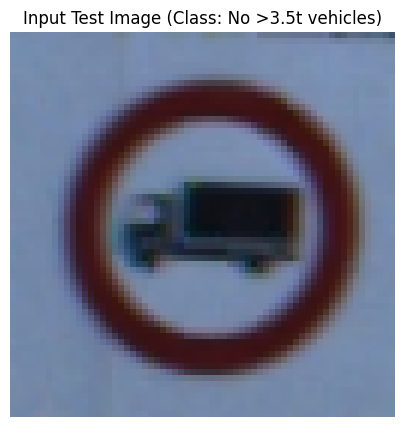

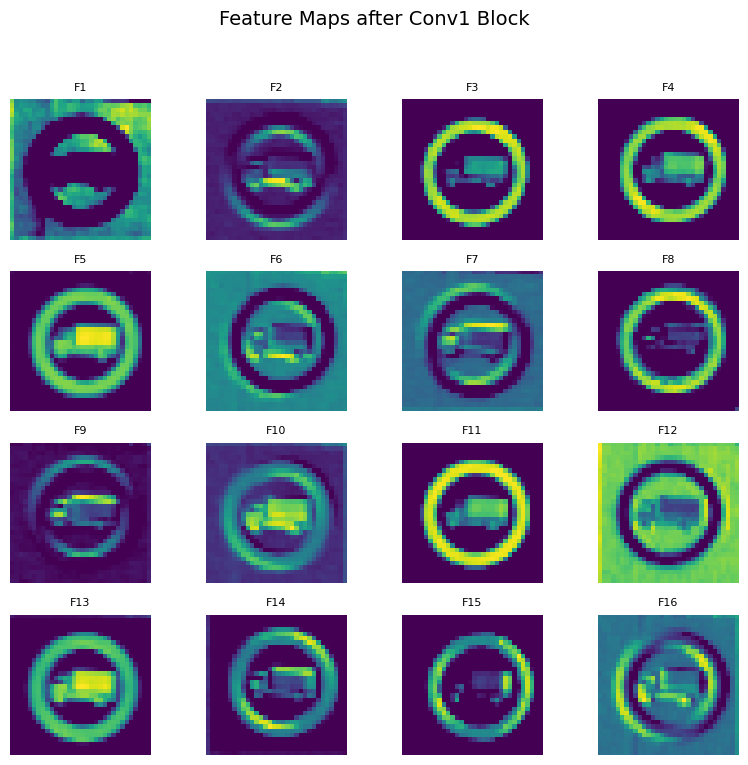

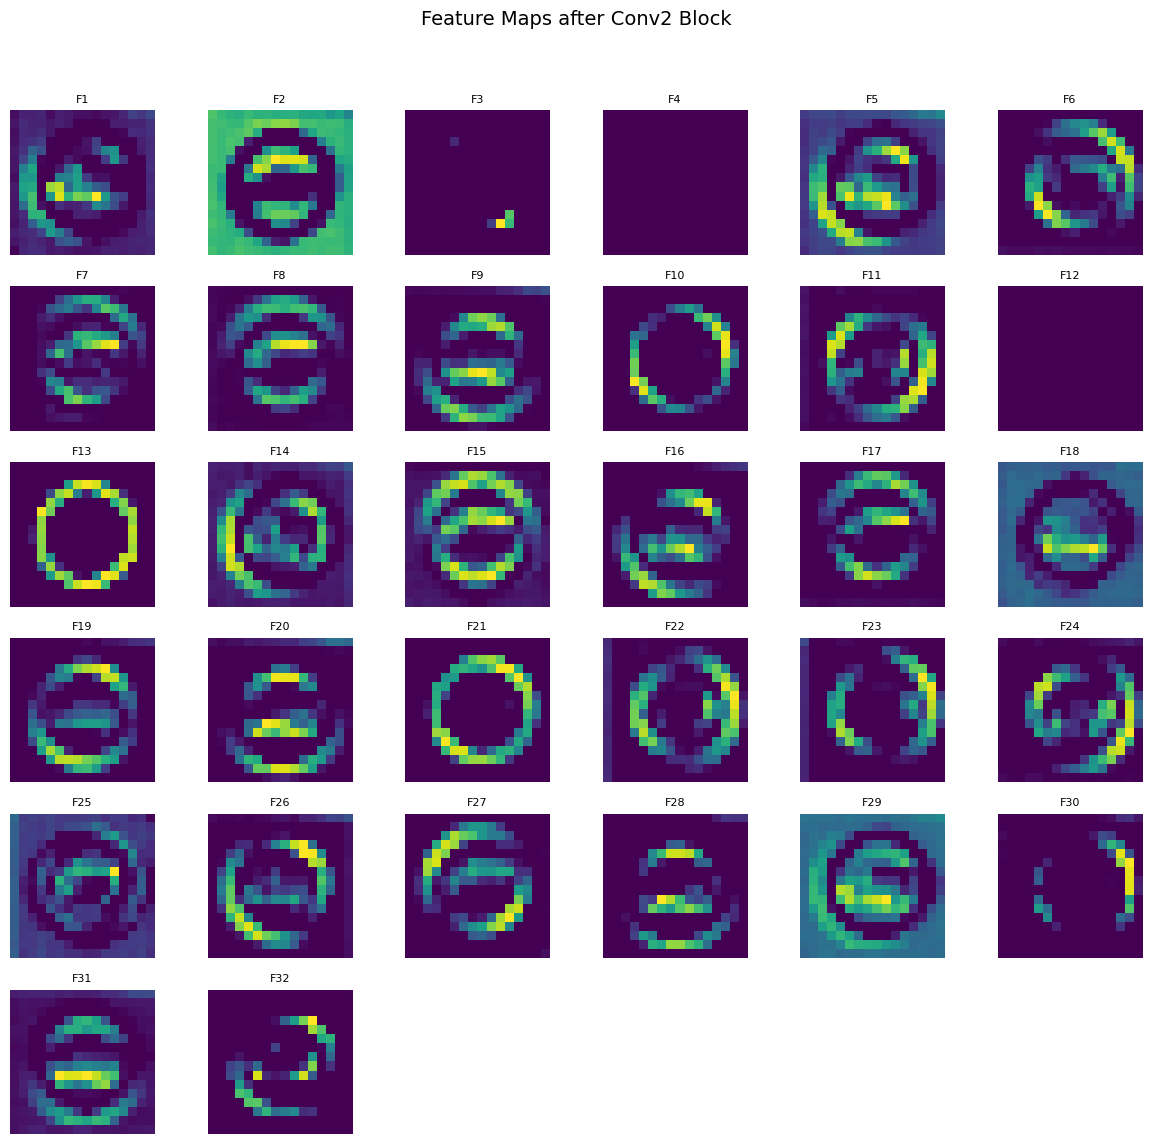

In [13]:
# Visualize CNN feature maps (best Deep CNN model)
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

def unnormalize_image(tensor):
    out = tensor.clone()
    for t, m, s in zip(out, mean, std):
        t.mul_(s).add_(m)
    return out.clamp(0, 1)

# Take one sample from test loader
dataiter = iter(test_loader)
images, labels = next(dataiter)
sample_image_tensor = images[0].unsqueeze(0).to(device)
original_image = unnormalize_image(images[0].cpu())

plt.figure(figsize=(5, 5))
plt.imshow(original_image.permute(1, 2, 0).numpy())
plt.title(f"Input Test Image (Class: {CLASS_NAMES[int(labels[0])]})")
plt.axis("off")
plt.show()


class FeatureExtractionCNN(nn.Module):
    def __init__(self, trained_model):
        super().__init__()
        self.conv1 = trained_model.conv1
        self.pool = trained_model.pool
        self.conv2 = trained_model.conv2

    def forward(self, x):
        f1 = self.pool(F.relu(self.conv1(x)))
        f2 = self.pool(F.relu(self.conv2(f1)))
        return f1, f2


feature_extractor = FeatureExtractionCNN(cnn_best_model).to(device)
feature_extractor.eval()

with torch.no_grad():
    feat1, feat2 = feature_extractor(sample_image_tensor)

feat1_np = feat1.squeeze(0).cpu().numpy()
feat2_np = feat2.squeeze(0).cpu().numpy()


def plot_feature_maps(features_np, title):
    num_filters = features_np.shape[0]
    grid_size = int(np.ceil(np.sqrt(num_filters)))

    plt.figure(figsize=(grid_size * 2, grid_size * 2))
    for i in range(num_filters):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(features_np[i], cmap="viridis")
        plt.title(f"F{i+1}", fontsize=8)
        plt.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


plot_feature_maps(feat1_np, "Feature Maps after Conv1 Block")
plot_feature_maps(feat2_np, "Feature Maps after Conv2 Block")

## Transfer Learning

In [14]:
# ImageNet normalization for pretrained backbones
tl_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

tl_train_ds = MyImageDataset(train_paths, train_labels, transform=tl_transforms)
tl_val_ds = MyImageDataset(val_paths, val_labels, transform=tl_transforms)
tl_test_ds = MyImageDataset(test_paths, test_labels, transform=tl_transforms)

BATCH_SIZE_TL = 128
NUM_WORKERS_TL = min(8, os.cpu_count() or 2)
PIN_MEMORY_TL = torch.cuda.is_available()

if NUM_WORKERS_TL > 0:
    tl_train_loader = DataLoader(tl_train_ds, batch_size=BATCH_SIZE_TL, shuffle=True, num_workers=NUM_WORKERS_TL,
                                 pin_memory=PIN_MEMORY_TL, persistent_workers=True, prefetch_factor=2)
    tl_val_loader = DataLoader(tl_val_ds, batch_size=BATCH_SIZE_TL, shuffle=False, num_workers=NUM_WORKERS_TL,
                               pin_memory=PIN_MEMORY_TL, persistent_workers=True, prefetch_factor=2)
    tl_test_loader = DataLoader(tl_test_ds, batch_size=BATCH_SIZE_TL, shuffle=False, num_workers=NUM_WORKERS_TL,
                                pin_memory=PIN_MEMORY_TL, persistent_workers=True, prefetch_factor=2)
else:
    tl_train_loader = DataLoader(tl_train_ds, batch_size=BATCH_SIZE_TL, shuffle=True)
    tl_val_loader = DataLoader(tl_val_ds, batch_size=BATCH_SIZE_TL, shuffle=False)
    tl_test_loader = DataLoader(tl_test_ds, batch_size=BATCH_SIZE_TL, shuffle=False)

print(f"TL loaders ready: Train={len(tl_train_ds):,}, Val={len(tl_val_ds):,}, Test={len(tl_test_ds):,}")
print(f"TL workers: {NUM_WORKERS_TL} | pin_memory={PIN_MEMORY_TL}")

TL loaders ready: Train=31,367, Val=7,842, Test=12,630
TL workers: 2 | pin_memory=True


In [15]:
def build_transfer_model_torch(base_model_name, num_classes=43):
    if base_model_name == "MobileNetV2":
        weights = tv_models.MobileNet_V2_Weights.IMAGENET1K_V1
        model = tv_models.mobilenet_v2(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
    elif base_model_name == "VGG16":
        weights = tv_models.VGG16_Weights.IMAGENET1K_V1
        model = tv_models.vgg16(weights=weights)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)
    else:
        raise ValueError("Unsupported model")

    return model


def set_trainable_layers(model, base_model_name, phase):
    if phase == 1:
        for p in model.parameters():
            p.requires_grad = False
        for p in model.classifier.parameters():
            p.requires_grad = True
    else:
        # Fine-tune: unfreeze upper layers only
        if base_model_name == "MobileNetV2":
            for p in model.features[-4:].parameters():
                p.requires_grad = True
        elif base_model_name == "VGG16":
            for p in model.features[-10:].parameters():
                p.requires_grad = True
        for p in model.classifier.parameters():
            p.requires_grad = True


def train_transfer_model(model, base_model_name, train_loader, val_loader, device, epochs_phase1=2, epochs_phase2=3):
    criterion = nn.CrossEntropyLoss()
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    # Phase 1: train classifier head
    set_trainable_layers(model, base_model_name, phase=1)
    optimizer_p1 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    scheduler_p1 = optim.lr_scheduler.StepLR(optimizer_p1, step_size=2, gamma=0.5)
    scaler_p1 = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    for epoch in range(epochs_phase1):
        tr_loss = train_one_epoch(model, train_loader, criterion, optimizer_p1, device, scaler=scaler_p1)
        val_acc, _, _ = evaluate_classifier(model, val_loader, device)
        scheduler_p1.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"[P1] Epoch {epoch+1}/{epochs_phase1} | Train Loss: {tr_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Phase 2: fine-tune top backbone layers
    set_trainable_layers(model, base_model_name, phase=2)
    optimizer_p2 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    scheduler_p2 = optim.lr_scheduler.StepLR(optimizer_p2, step_size=2, gamma=0.5)
    scaler_p2 = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    for epoch in range(epochs_phase2):
        tr_loss = train_one_epoch(model, train_loader, criterion, optimizer_p2, device, scaler=scaler_p2)
        val_acc, _, _ = evaluate_classifier(model, val_loader, device)
        scheduler_p2.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"[P2] Epoch {epoch+1}/{epochs_phase2} | Train Loss: {tr_loss:.4f} | Val Acc: {val_acc:.4f}")

    model.load_state_dict(best_state)
    return model, best_val_acc


models_to_compare = ["MobileNetV2", "VGG16"]
results_tl = []

for model_name in models_to_compare:
    print("\n" + "=" * 80)
    print(f"Transfer Learning with {model_name} (PyTorch)")
    print("=" * 80)

    start_time = time.time()
    tl_model = build_transfer_model_torch(model_name, num_classes=NUM_CLASSES).to(device)

    tl_model, best_val_acc = train_transfer_model(
        tl_model,
        model_name,
        tl_train_loader,
        tl_val_loader,
        device,
        epochs_phase1=2,
        epochs_phase2=3,
    )

    test_acc, y_true_tl, y_pred_tl = evaluate_classifier(tl_model, tl_test_loader, device)
    elapsed = time.time() - start_time

    results_tl.append({
        "Base Model": model_name,
        "Optimizer": "AdamW",
        "Scheduler": "StepLR",
        "Best Val Acc": best_val_acc,
        "Test Acc": test_acc,
        "Time (s)": elapsed,
    })

    print(f"{model_name} Test Accuracy: {test_acc:.4f}")

results_tl_df = pd.DataFrame(results_tl).sort_values(by="Test Acc", ascending=False)
print("\nTransfer Learning Results (single optimizer/scheduler):")
print(results_tl_df.to_string(index=False))


Transfer Learning with MobileNetV2 (PyTorch)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 129MB/s]


[P1] Epoch 1/2 | Train Loss: 1.4646 | Val Acc: 0.7692
[P1] Epoch 2/2 | Train Loss: 0.7526 | Val Acc: 0.8191
[P2] Epoch 1/3 | Train Loss: 0.2475 | Val Acc: 0.9661
[P2] Epoch 2/3 | Train Loss: 0.0740 | Val Acc: 0.9810
[P2] Epoch 3/3 | Train Loss: 0.0294 | Val Acc: 0.9852
MobileNetV2 Test Accuracy: 0.9081

Transfer Learning with VGG16 (PyTorch)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 65.7MB/s]


[P1] Epoch 1/2 | Train Loss: 0.6150 | Val Acc: 0.9588
[P1] Epoch 2/2 | Train Loss: 0.2518 | Val Acc: 0.9684
[P2] Epoch 1/3 | Train Loss: 0.0598 | Val Acc: 0.9883
[P2] Epoch 2/3 | Train Loss: 0.0221 | Val Acc: 0.9922
[P2] Epoch 3/3 | Train Loss: 0.0062 | Val Acc: 0.9967
VGG16 Test Accuracy: 0.9485

Transfer Learning Results (single optimizer/scheduler):
 Base Model Optimizer Scheduler  Best Val Acc  Test Acc   Time (s)
      VGG16     AdamW    StepLR      0.996685  0.948535 710.121168
MobileNetV2     AdamW    StepLR      0.985208  0.908076 465.442013


In [16]:
# AutoEncoder setup
NOISE_FACTOR = 0.1
NUM_EPOCHS_AE = 15
LR_AE = 5e-4

# Use [0, 1] tensors for reconstruction task (no ImageNet normalization)
ae_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

ae_train_ds = MyImageDataset(train_paths, train_labels, transform=ae_transforms)
ae_val_ds = MyImageDataset(val_paths, val_labels, transform=ae_transforms)
ae_test_ds = MyImageDataset(test_paths, test_labels, transform=ae_transforms)

NUM_WORKERS_AE = min(8, os.cpu_count() or 2)
PIN_MEMORY_AE = torch.cuda.is_available()

if NUM_WORKERS_AE > 0:
    ae_train_loader = DataLoader(ae_train_ds, batch_size=64, shuffle=True, num_workers=NUM_WORKERS_AE,
                                 pin_memory=PIN_MEMORY_AE, persistent_workers=True, prefetch_factor=2)
    ae_val_loader = DataLoader(ae_val_ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS_AE,
                               pin_memory=PIN_MEMORY_AE, persistent_workers=True, prefetch_factor=2)
    ae_test_loader = DataLoader(ae_test_ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS_AE,
                                pin_memory=PIN_MEMORY_AE, persistent_workers=True, prefetch_factor=2)
else:
    ae_train_loader = DataLoader(ae_train_ds, batch_size=64, shuffle=True)
    ae_val_loader = DataLoader(ae_val_ds, batch_size=64, shuffle=False)
    ae_test_loader = DataLoader(ae_test_ds, batch_size=64, shuffle=False)

print(f"AE loaders ready: Train={len(ae_train_ds):,}, Val={len(ae_val_ds):,}, Test={len(ae_test_ds):,}")
print(f"AE workers: {NUM_WORKERS_AE} | pin_memory={PIN_MEMORY_AE}")

AE loaders ready: Train=31,367, Val=7,842, Test=12,630
AE workers: 2 | pin_memory=True


In [17]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
        )


        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [18]:
denoise_model = DenoisingAutoencoder().to(device)
criterion_ae = nn.L1Loss()
optimizer_ae = optim.Adam(denoise_model.parameters(), lr=LR_AE)

In [19]:
def evaluate_autoencoder(model, data_loader, noise_factor, device):
    model.eval()
    mae_total = 0.0
    mse_total = 0.0
    batches = 0

    with torch.inference_mode():
        for images, _ in data_loader:
            images = images.to(device, non_blocking=True)
            noisy = images + noise_factor * torch.randn_like(images)
            noisy = torch.clamp(noisy, 0.0, 1.0)

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
                outputs = model(noisy)

            mae = F.l1_loss(outputs, images).item()
            mse = F.mse_loss(outputs, images).item()

            mae_total += mae
            mse_total += mse
            batches += 1

    return mae_total / batches, mse_total / batches


def train_autoencoder(model, train_loader, val_loader, num_epochs, noise_factor, device):
    best_val_mae = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for images, _ in train_loader:
            images = images.to(device, non_blocking=True)

            noisy = images + noise_factor * torch.randn_like(images)
            noisy = torch.clamp(noisy, 0.0, 1.0)

            optimizer_ae.zero_grad(set_to_none=True)

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
                outputs = model(noisy)
                loss = criterion_ae(outputs, images)

            if device.type == "cuda":
                scaler.scale(loss).backward()
                scaler.step(optimizer_ae)
                scaler.update()
            else:
                loss.backward()
                optimizer_ae.step()

            train_loss += loss.item()

        val_mae, val_mse = evaluate_autoencoder(model, val_loader, noise_factor, device)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train MAE: {train_loss / len(train_loader):.4f} | "
            f"Val MAE: {val_mae:.4f} | Val MSE: {val_mse:.4f}"
        )

    model.load_state_dict(best_state)
    return model

In [20]:
print("Training AutoEncoder...")
denoise_model = train_autoencoder(
    model=denoise_model,
    train_loader=ae_train_loader,
    val_loader=ae_val_loader,
    num_epochs=NUM_EPOCHS_AE,
    noise_factor=NOISE_FACTOR,
    device=device,
)

mae_test, mse_test = evaluate_autoencoder(denoise_model, ae_test_loader, NOISE_FACTOR, device)
print(f"\nAutoEncoder Test MAE: {mae_test:.4f}")
print(f"AutoEncoder Test MSE: {mse_test:.4f}")

Training AutoEncoder...
Epoch [1/15] | Train MAE: 0.0443 | Val MAE: 0.0288 | Val MSE: 0.0018
Epoch [2/15] | Train MAE: 0.0297 | Val MAE: 0.0252 | Val MSE: 0.0015
Epoch [3/15] | Train MAE: 0.0273 | Val MAE: 0.0236 | Val MSE: 0.0013
Epoch [4/15] | Train MAE: 0.0256 | Val MAE: 0.0229 | Val MSE: 0.0012
Epoch [5/15] | Train MAE: 0.0248 | Val MAE: 0.0222 | Val MSE: 0.0012
Epoch [6/15] | Train MAE: 0.0239 | Val MAE: 0.0224 | Val MSE: 0.0012
Epoch [7/15] | Train MAE: 0.0234 | Val MAE: 0.0241 | Val MSE: 0.0013
Epoch [8/15] | Train MAE: 0.0233 | Val MAE: 0.0219 | Val MSE: 0.0011
Epoch [9/15] | Train MAE: 0.0230 | Val MAE: 0.0212 | Val MSE: 0.0011
Epoch [10/15] | Train MAE: 0.0227 | Val MAE: 0.0215 | Val MSE: 0.0011
Epoch [11/15] | Train MAE: 0.0225 | Val MAE: 0.0212 | Val MSE: 0.0011
Epoch [12/15] | Train MAE: 0.0222 | Val MAE: 0.0213 | Val MSE: 0.0010
Epoch [13/15] | Train MAE: 0.0220 | Val MAE: 0.0212 | Val MSE: 0.0010
Epoch [14/15] | Train MAE: 0.0219 | Val MAE: 0.0215 | Val MSE: 0.0010
Epoch

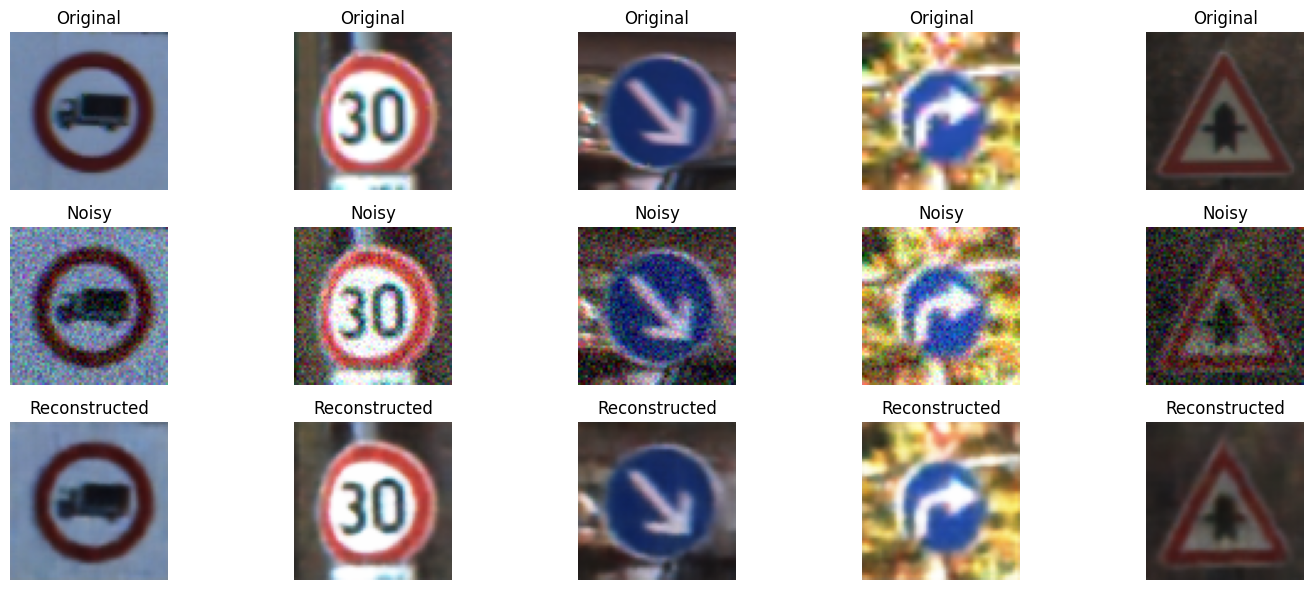

In [21]:
# Visualize AutoEncoder reconstruction on test set
denoise_model.eval()

images, _ = next(iter(ae_test_loader))
images = images.to(device)

noisy = images + NOISE_FACTOR * torch.randn_like(images)
noisy = torch.clamp(noisy, 0.0, 1.0)

with torch.no_grad():
    reconstructed = denoise_model(noisy)

num_samples = 5
plt.figure(figsize=(15, 6))

for i in range(num_samples):
    plt.subplot(3, num_samples, i + 1)
    plt.imshow(images[i].cpu().permute(1, 2, 0))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3, num_samples, i + 1 + num_samples)
    plt.imshow(noisy[i].cpu().permute(1, 2, 0))
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3, num_samples, i + 1 + 2 * num_samples)
    plt.imshow(reconstructed[i].cpu().permute(1, 2, 0))
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()